In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import ccf

In [3]:
df = pd.read_csv("C:/Users/qtg4ys/Documents/DS3001/DS4002/weather_crime_final.csv")
df.head()

,city,date,total_crime_count,violent_count,property_count,other_count,Daily Temperature Mean,Daily Precipitation Sum
0,Charlottesville,2022-01-01,15,0,2,13,14.7,9.0
1,Charlottesville,2022-01-02,11,0,2,9,15.4,16.9
2,Charlottesville,2022-01-03,8,0,1,7,0.9,29.4
3,Charlottesville,2022-01-04,16,0,1,15,-6.4,0.0
4,Charlottesville,2022-01-05,12,0,0,12,0.2,0.0


In [6]:
#Configuration

DATA_PATH = "C:/Users/qtg4ys/Documents/DS3001/DS4002/weather_crime_final.csv"
 
SMALL_CITIES = ["Charlottesville", "Durham"]
LARGE_CITIES = ["Chicago", "NYC"]
CITY_ORDER   = SMALL_CITIES + LARGE_CITIES
 
PALETTE_CITY = {
    "Charlottesville": "#4C72B0",
    "Durham":          "#DD8452",
    "Chicago":         "#55A868",
    "NYC":             "#C44E52",
}
PALETTE_SIZE = {"Small": "#4C72B0", "Large": "#C44E52"}
 
sns.set_theme(style="whitegrid", font_scale=1.1)

In [8]:
#Load and Prep Data

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["city_size"] = df["city"].apply(lambda c: "Small" if c in SMALL_CITIES else "Large")
 
# Temperature bins
df["temp_bin"] = pd.cut(
    df["Daily Temperature Mean"],
    bins=4,
    labels=["Cold", "Cool", "Warm", "Hot"]
)
 
# Rain flag
df["rain"] = (df["Daily Precipitation Sum"] > 0).map({True: "Rain", False: "No Rain"})


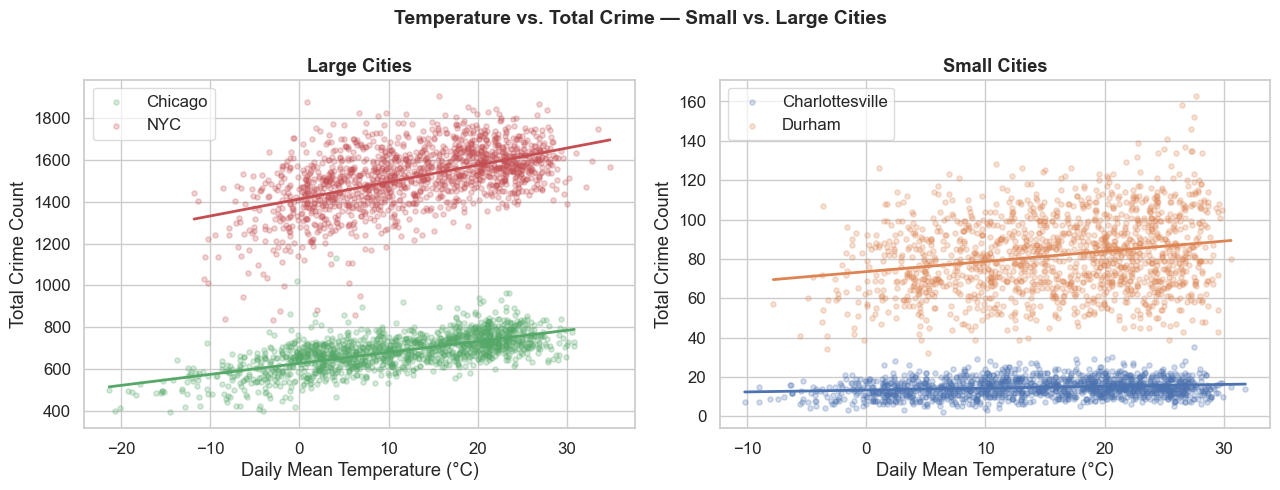

In [9]:
# Scatter + regression lines: small vs large

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, (size, group) in zip(axes, df.groupby("city_size")):
    for city, cdf in group.groupby("city"):
        ax.scatter(
            cdf["Daily Temperature Mean"], cdf["total_crime_count"],
            alpha=0.25, s=14, color=PALETTE_CITY[city], label=city
        )
        m, b, *_ = stats.linregress(
            cdf["Daily Temperature Mean"].dropna(),
            cdf["total_crime_count"].dropna()
        )
        x_range = np.linspace(cdf["Daily Temperature Mean"].min(),
                              cdf["Daily Temperature Mean"].max(), 100)
        ax.plot(x_range, m * x_range + b, color=PALETTE_CITY[city], linewidth=2)
 
    ax.set_title(f"{size} Cities", fontweight="bold")
    ax.set_xlabel("Daily Mean Temperature (°C)")
    ax.set_ylabel("Total Crime Count")
    ax.legend(framealpha=0.7)
 
fig.suptitle("Temperature vs. Total Crime — Small vs. Large Cities", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_scatter_by_city_size.png", dpi=150)
plt.show()

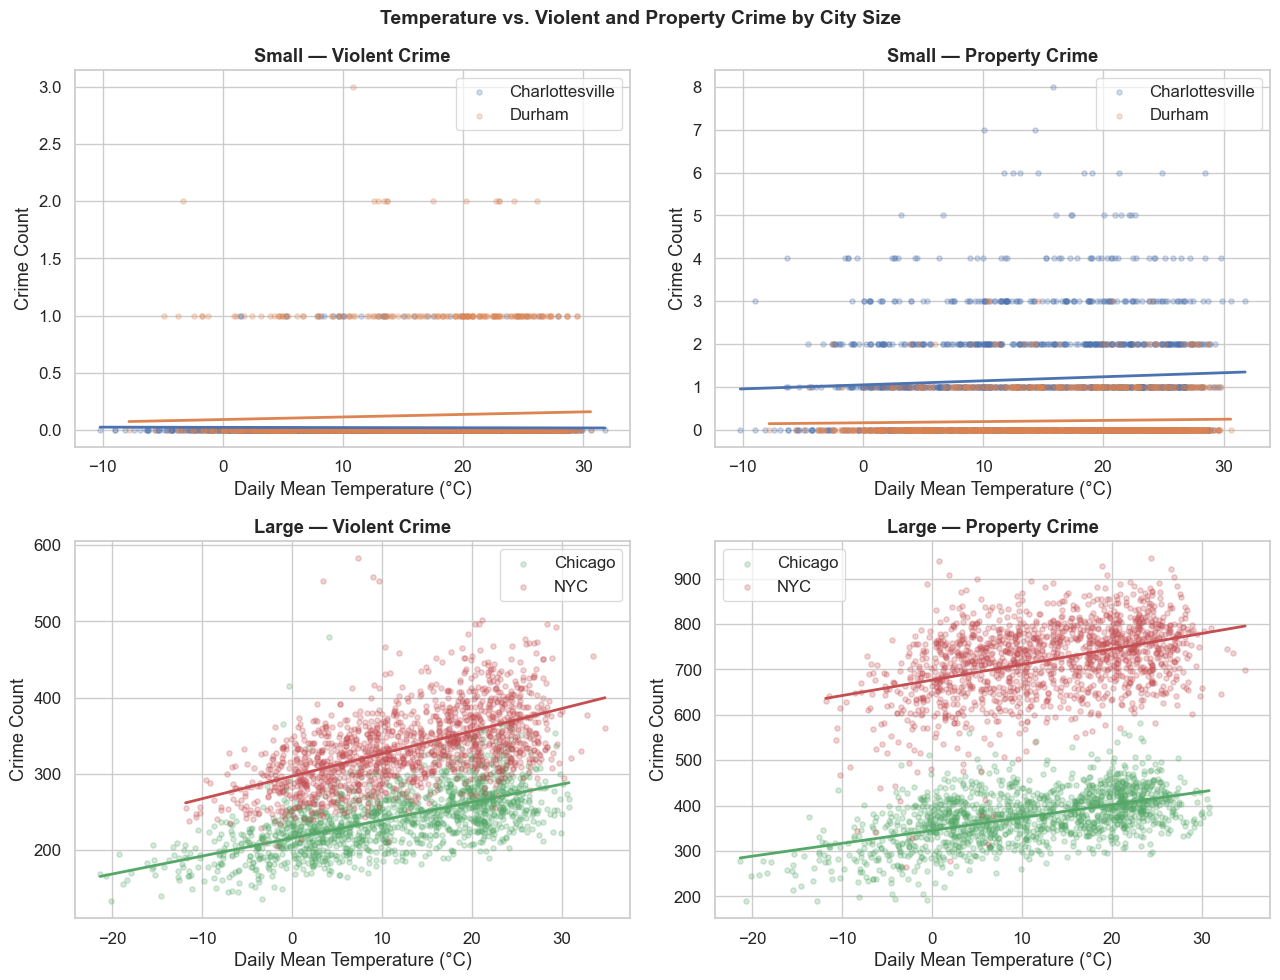

In [10]:
#Scatter: violent vs property crime, by city size

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
crime_types = ["violent_count", "property_count"]
sizes       = ["Small", "Large"]
 
for row, size in enumerate(sizes):
    sub = df[df["city_size"] == size]
    for col, crime in enumerate(crime_types):
        ax = axes[row][col]
        for city, cdf in sub.groupby("city"):
            ax.scatter(
                cdf["Daily Temperature Mean"], cdf[crime],
                alpha=0.25, s=14, color=PALETTE_CITY[city], label=city
            )
            valid = cdf[["Daily Temperature Mean", crime]].dropna()
            if len(valid) > 2:
                m, b, *_ = stats.linregress(
                    valid["Daily Temperature Mean"], valid[crime]
                )
                x_range = np.linspace(valid["Daily Temperature Mean"].min(),
                                      valid["Daily Temperature Mean"].max(), 100)
                ax.plot(x_range, m * x_range + b, color=PALETTE_CITY[city], linewidth=2)
 
        ax.set_title(f"{size} — {crime.replace('_count','').title()} Crime",
                     fontweight="bold")
        ax.set_xlabel("Daily Mean Temperature (°C)")
        ax.set_ylabel("Crime Count")
        ax.legend(framealpha=0.7)
 
fig.suptitle("Temperature vs. Violent and Property Crime by City Size",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_violent_property_scatter.png", dpi=150)
plt.show()

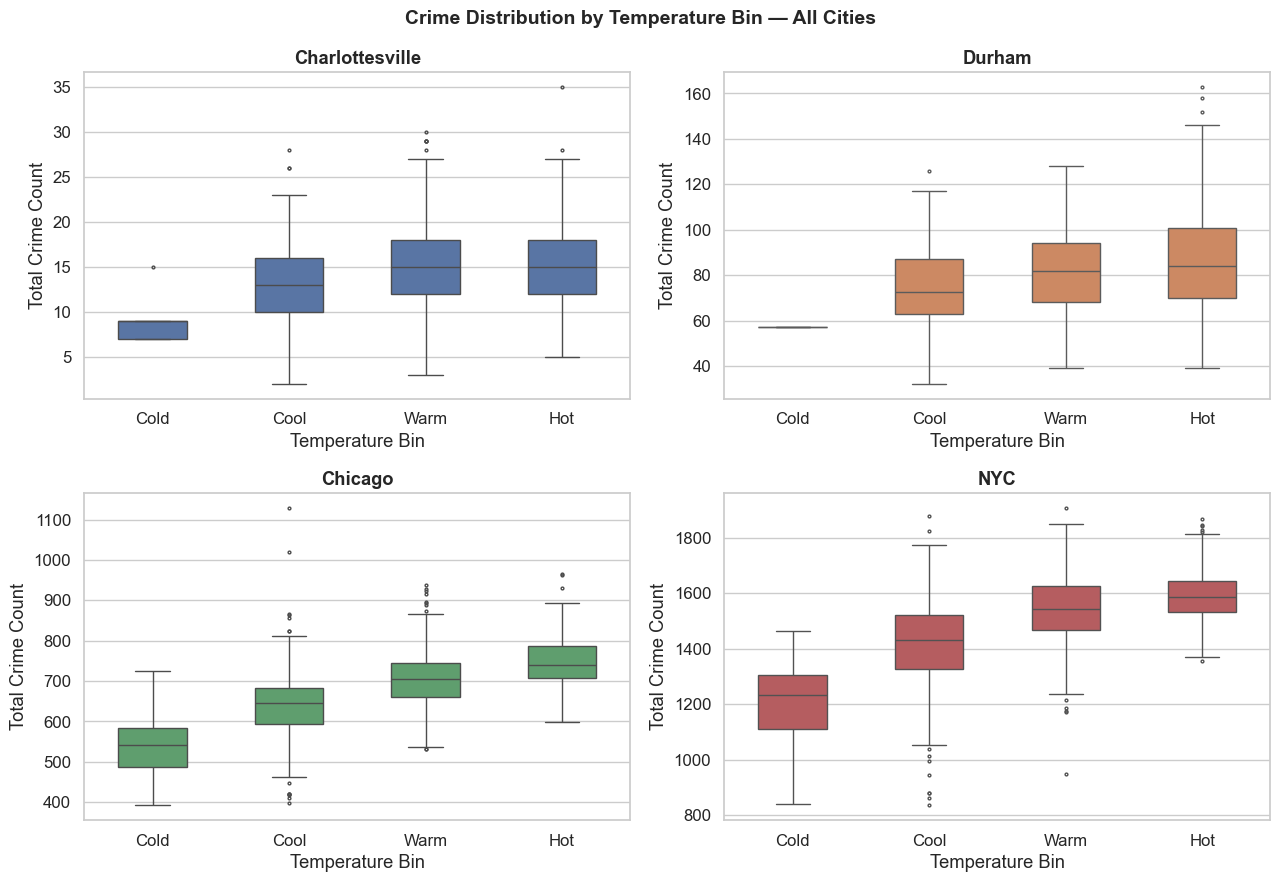

In [12]:
#Binned temp boxplots, faceted by city

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
axes_flat = axes.flatten()
 
for ax, city in zip(axes_flat, CITY_ORDER):
    sub = df[df["city"] == CITY_ORDER[CITY_ORDER.index(city)]]
    sns.boxplot(
        data=sub, x="temp_bin", y="total_crime_count",
        order=["Cold", "Cool", "Warm", "Hot"],
        color=PALETTE_CITY[city], ax=ax, width=0.5, fliersize=2
    )
    ax.set_title(city, fontweight="bold")
    ax.set_xlabel("Temperature Bin")
    ax.set_ylabel("Total Crime Count")
 
fig.suptitle("Crime Distribution by Temperature Bin — All Cities",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_temp_bin_boxplots.png", dpi=150)
plt.show()

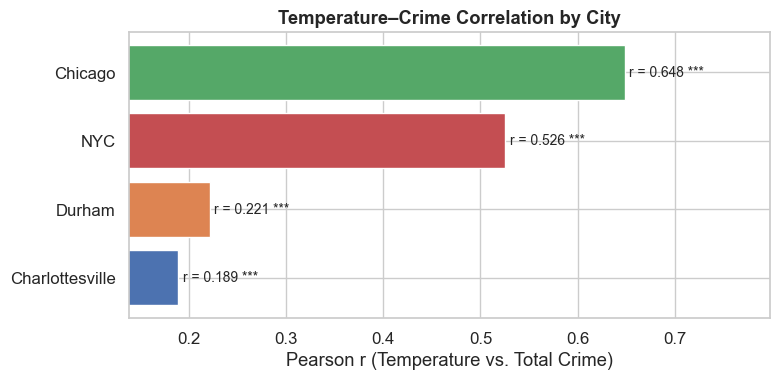

In [14]:
#Per-city correlation bar chart

corr_rows = []
for city, cdf in df.groupby("city"):
    valid = cdf[["Daily Temperature Mean", "total_crime_count"]].dropna()
    r, p  = stats.pearsonr(valid["Daily Temperature Mean"], valid["total_crime_count"])
    corr_rows.append({"city": city, "pearson_r": r, "p_value": p,
                      "city_size": "Small" if city in SMALL_CITIES else "Large"})
 
corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r")
 
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    corr_df["city"], corr_df["pearson_r"],
    color=[PALETTE_CITY[c] for c in corr_df["city"]]
)
for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = "***" if row["p_value"] < 0.001 else ("**" if row["p_value"] < 0.01 else
          ("*" if row["p_value"] < 0.05 else "ns"))
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"r = {row['pearson_r']:.3f} {sig}", va="center", fontsize=10)
 
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r (Temperature vs. Total Crime)")
ax.set_title("Temperature–Crime Correlation by City", fontweight="bold")
ax.set_xlim(corr_df["pearson_r"].min() - 0.05, corr_df["pearson_r"].max() + 0.15)
plt.tight_layout()
plt.savefig("fig4_correlation_bar.png", dpi=150)
plt.show()

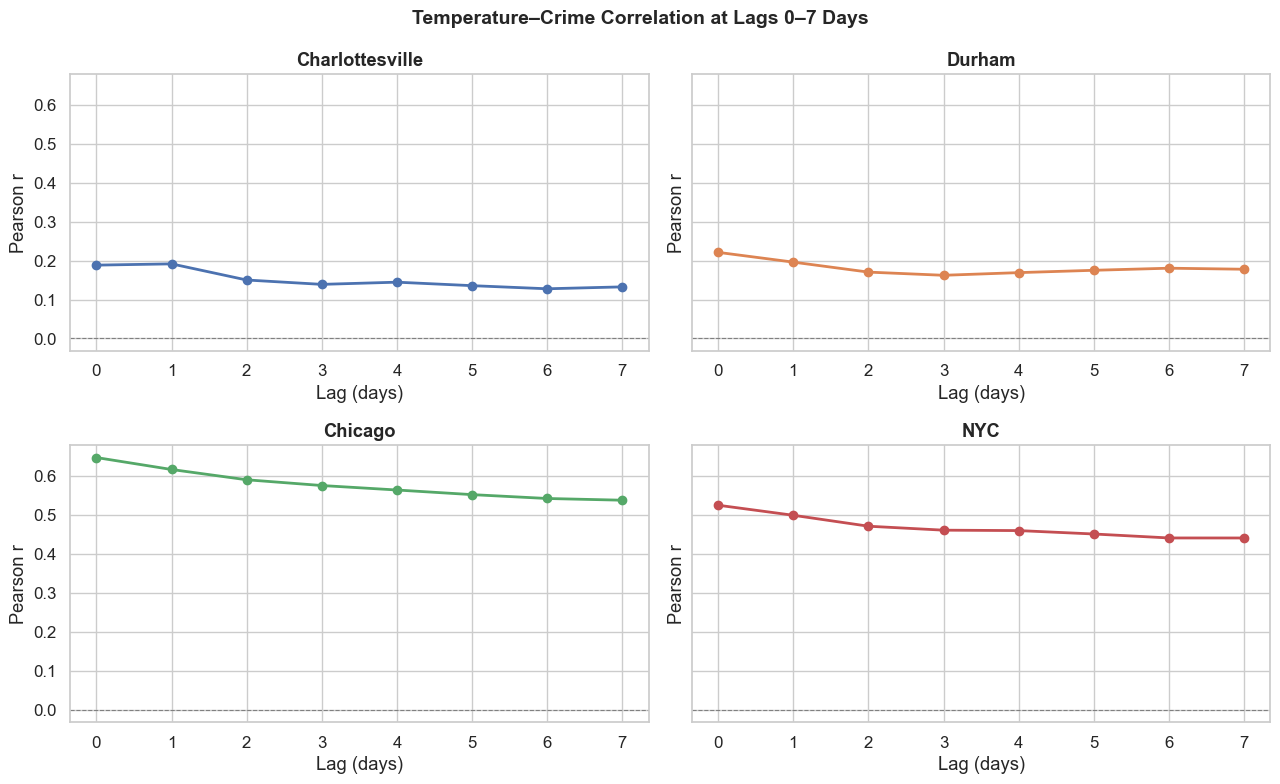

In [16]:
#Lagged correlation line plot (lags 0–7 days)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes_flat = axes.flatten()
lags      = range(0, 8)
 
for ax, city in zip(axes_flat, CITY_ORDER):
    sub   = df[df["city"] == city].sort_values("date")
    temp  = sub["Daily Temperature Mean"].values
    crime = sub["total_crime_count"].values
    lag_r = []
    for lag in lags:
        t = temp[:-lag] if lag > 0 else temp
        c = crime[lag:]  if lag > 0 else crime
        r, _ = stats.pearsonr(t, c)
        lag_r.append(r)
 
    ax.plot(list(lags), lag_r, marker="o", color=PALETTE_CITY[city], linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(city, fontweight="bold")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Pearson r")
    ax.set_xticks(list(lags))
 
fig.suptitle("Temperature–Crime Correlation at Lags 0–7 Days",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_lagged_correlation.png", dpi=150)
plt.show()

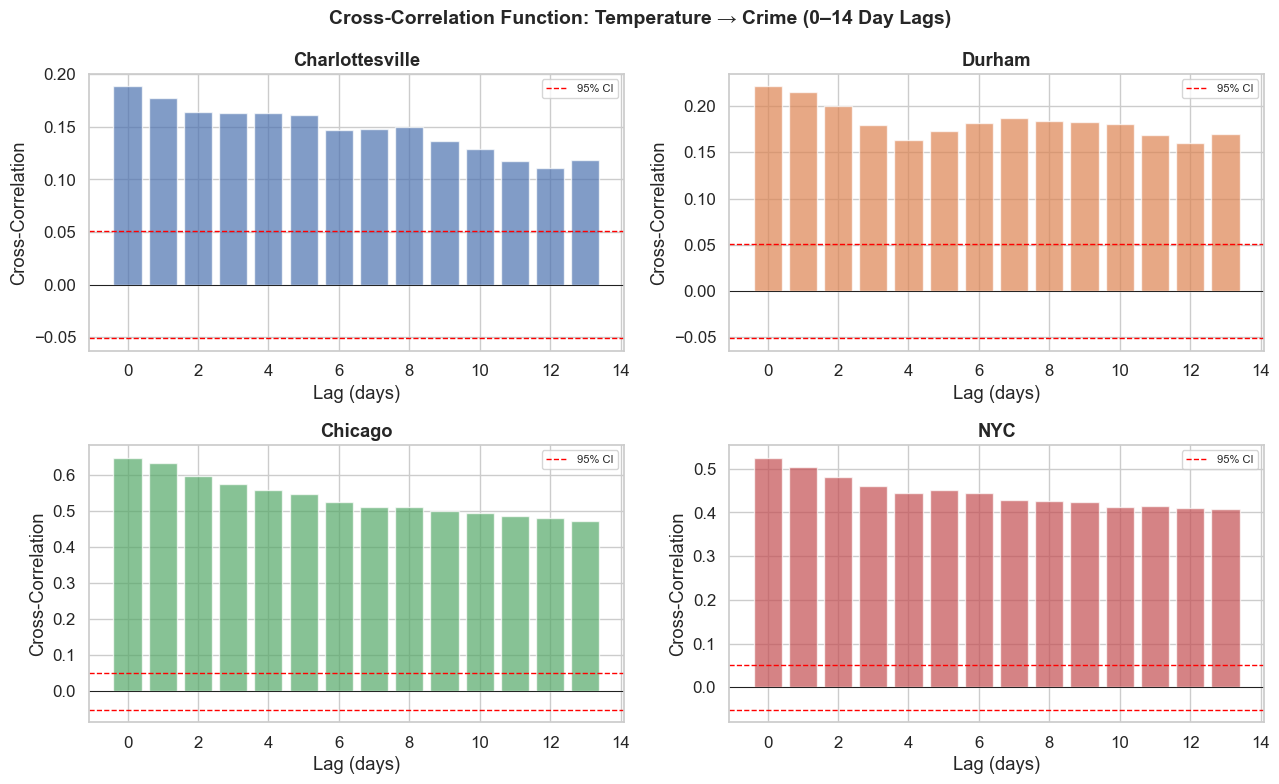

In [21]:
#CCF plots (formal cross-correlation)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
axes_flat = axes.flatten()
N_LAGS    = 14
 
for ax, city in zip(axes_flat, CITY_ORDER):
    sub      = df[df["city"] == city].sort_values("date")
    temp_z   = stats.zscore(sub["Daily Temperature Mean"].ffill())
    crime_z  = stats.zscore(sub["total_crime_count"].ffill())
    ccf_vals = ccf(temp_z, crime_z, nlags=N_LAGS, alpha=None)
 
    # ccf returns nlags+1 values (lag 0 … nlags); match x-axis length to output
    x_lags = range(len(ccf_vals))
    conf = 1.96 / np.sqrt(len(temp_z))
    ax.bar(x_lags, ccf_vals, color=PALETTE_CITY[city], alpha=0.7)
    ax.axhline( conf, color="red", linestyle="--", linewidth=1, label="95% CI")
    ax.axhline(-conf, color="red", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(city, fontweight="bold")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Cross-Correlation")
    ax.legend(fontsize=8)
 
fig.suptitle("Cross-Correlation Function: Temperature → Crime (0–14 Day Lags)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig6_ccf_plots.png", dpi=150)
plt.show()
 

C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\2100239356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\2100239356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\2100239356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\2100239356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

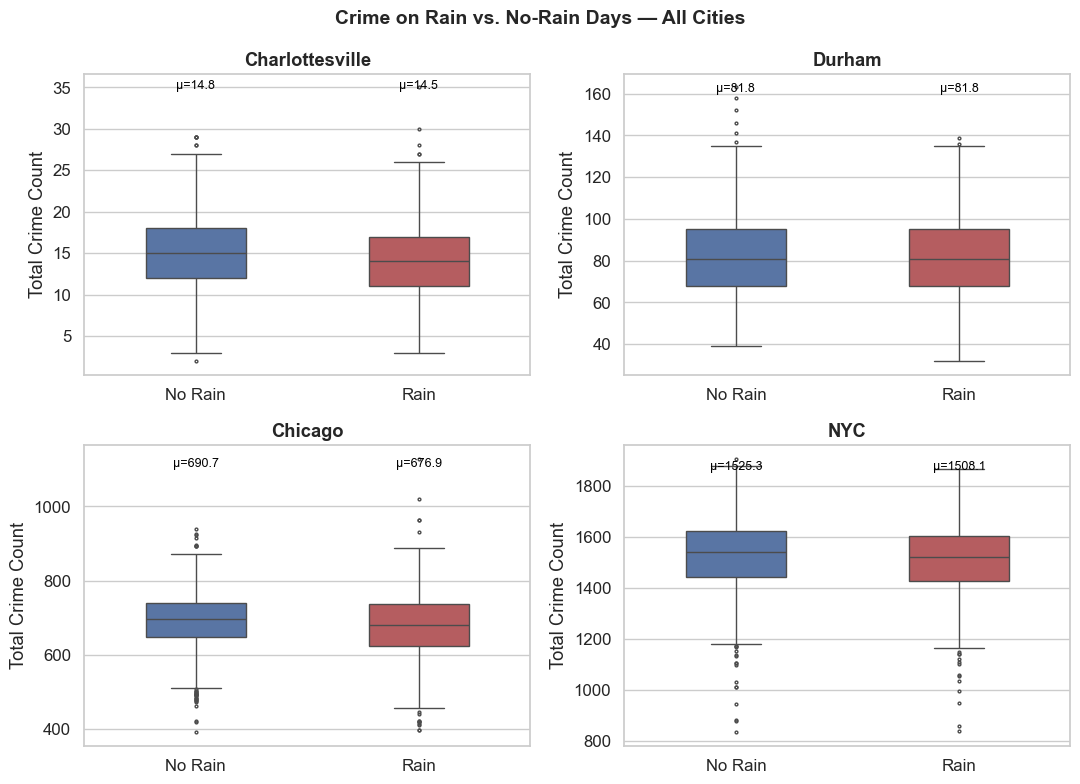

In [18]:
#Rain vs no-rain boxplots by city

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
axes_flat = axes.flatten()
 
for ax, city in zip(axes_flat, CITY_ORDER):
    sub = df[df["city"] == city]
    sns.boxplot(
        data=sub, x="rain", y="total_crime_count",
        order=["No Rain", "Rain"],
        palette={"No Rain": "#4C72B0", "Rain": "#C44E52"},
        ax=ax, width=0.45, fliersize=2
    )
    # Annotate with means
    for i, label in enumerate(["No Rain", "Rain"]):
        mean_val = sub[sub["rain"] == label]["total_crime_count"].mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f"μ={mean_val:.1f}",
                ha="center", fontsize=9, color="black")
    ax.set_title(city, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Total Crime Count")
 
fig.suptitle("Crime on Rain vs. No-Rain Days — All Cities",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig7_rain_boxplots.png", dpi=150)
plt.show()

C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\1425067733.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = sub.groupby(["temp_half", "rain"])["total_crime_count"].mean().unstack()
C:\Users\qtg4ys\AppData\Local\Temp\ipykernel_27548\1425067733.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = sub.groupby(["temp_half", "rain"])["total_crime_count"].mean().unstack()


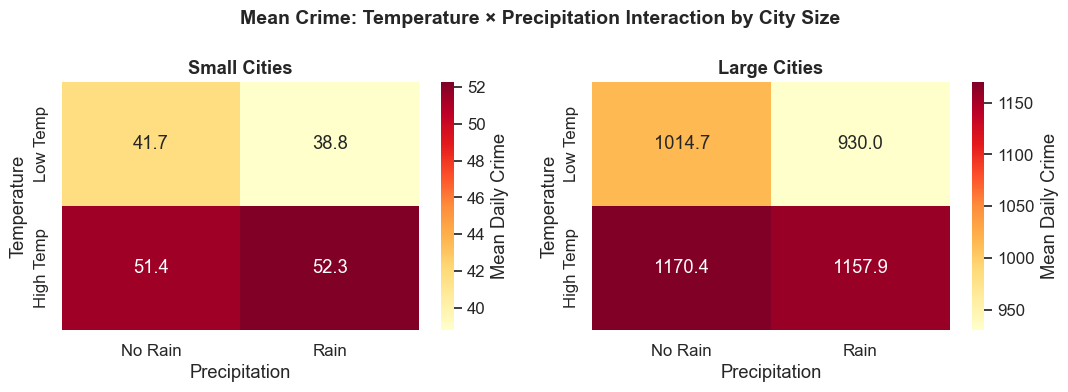

In [19]:
#2×2 heatmap: temp × rain, mean crime, faceted by city size

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
for ax, size in zip(axes, ["Small", "Large"]):
    sub = df[df["city_size"] == size].copy()
    sub["temp_half"] = pd.cut(
        sub["Daily Temperature Mean"],
        bins=2, labels=["Low Temp", "High Temp"]
    )
    pivot = sub.groupby(["temp_half", "rain"])["total_crime_count"].mean().unstack()
    pivot = pivot.reindex(index=["Low Temp", "High Temp"],
                          columns=["No Rain", "Rain"])
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="YlOrRd",
        ax=ax, cbar_kws={"label": "Mean Daily Crime"}
    )
    ax.set_title(f"{size} Cities", fontweight="bold")
    ax.set_xlabel("Precipitation")
    ax.set_ylabel("Temperature")
 
fig.suptitle("Mean Crime: Temperature × Precipitation Interaction by City Size",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_temp_rain_heatmap.png", dpi=150)
plt.show()